In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LinearSegmentedColormap

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / 'seacofs_tilt_tools.py').exists()), None)
CASE_ROOT = ANALYSIS_ROOT / 'case_studies'
FLOW_ROOT = ANALYSIS_ROOT / 'beta_effect_background_flow'
ELLIPSE_ROOT = ANALYSIS_ROOT / 'ellipse_tilt_analysis'
for path in (ANALYSIS_ROOT, CASE_ROOT, FLOW_ROOT, ELLIPSE_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from background_flow_tools import BackgroundConfig, load_background_cache
import ellipse_tilt_tools as et

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)

In [2]:
ELLIPSE_FRAC = 1.0
USE_PV_CACHE=True

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_eddies = tilt.add_pv_gradient_terms(
    df_eddies,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_max_abs_w=True,
    max_depth_m=1000,
    use_cache=USE_PV_CACHE,
)
df_eddies = tilt.add_region_labels(df_eddies, grid)

# Surface ellipse geometry and axial tilt alignment (0° parallel, 90° perpendicular).
df_eddies = et.ellipse_geometry(df_eddies)
df_eddies['TiltMajorAlignmentDeg'] = np.abs(
    et.axial_difference(df_eddies.TiltDir, df_eddies.MajorBearing)
)

# Primary environmental shear used in the background-flow analysis:
# centred seasonal climatology, surface minus the 200–500 m layer mean.
background = load_background_cache(BackgroundConfig()).drop(
    columns=['ic', 'jc'], errors='ignore'
)
needed = {'clim_surface_east_ms', 'clim_surface_north_ms',
          'clim_200_east_ms', 'clim_200_north_ms',
          'clim_500_east_ms', 'clim_500_north_ms'}
missing = needed - set(background.columns)
if missing:
    raise RuntimeError(f'Background cache is missing {sorted(missing)}')
df_eddies = df_eddies.merge(
    background[['Eddy', 'Day', *sorted(needed)]],
    on=['Eddy', 'Day'], how='left', validate='one_to_one'
)
for component in ('east', 'north'):
    deep = (500 * df_eddies[f'clim_500_{component}_ms']
            - 200 * df_eddies[f'clim_200_{component}_ms']) / 300
    df_eddies[f'clim_upper_minus_deep_{component}_ms'] = (
        df_eddies[f'clim_200_{component}_ms'] - deep
    )
SHEAR_E = 'clim_upper_minus_deep_east_ms'
SHEAR_N = 'clim_upper_minus_deep_north_ms'

In [3]:
d = df_eddies.groupby('Eddy').filter(lambda x: x.Region.isin(['S1','S2']).all())
top10 = d.groupby('Eddy').Age.max().nlargest(10).index.tolist()
list(top10)

[596, 376, 1656, 1453, 2298, 886, 1759, 1188, 2281, 1355]

In [4]:
df_eddies.columns


Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       ...
       'Q_valid', 'TiltMajorAlignmentDeg', 'clim_200_east_ms',
       'clim_200_north_ms', 'clim_500_east_ms', 'clim_500_north_ms',
       'clim_surface_east_ms', 'clim_surface_north_ms',
       'clim_upper_minus_deep_east_ms', 'clim_upper_minus_deep_north_ms'],
      dtype='object', length=101)

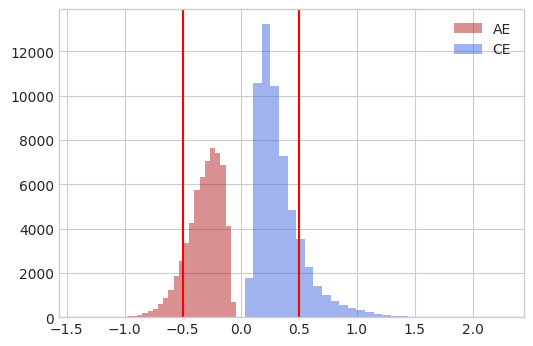

In [5]:
df = df_eddies.copy()
fig,ax=plt.subplots(figsize=(6,4))
for cyc,c in [('AE','firebrick'),('CE','royalblue')]:
    df.loc[df.Cyc.eq(cyc),'Ro'].hist(ax=ax,bins=30,alpha=.5,color=c,label=cyc)
ax.legend()
ax.axvline(.5, color='r'); ax.axvline(-.5, color='r')

Low Ro
AE mean tilt dir -10, tilt dis 26 km
CE mean tilt dir -134, tilt dis 18 km


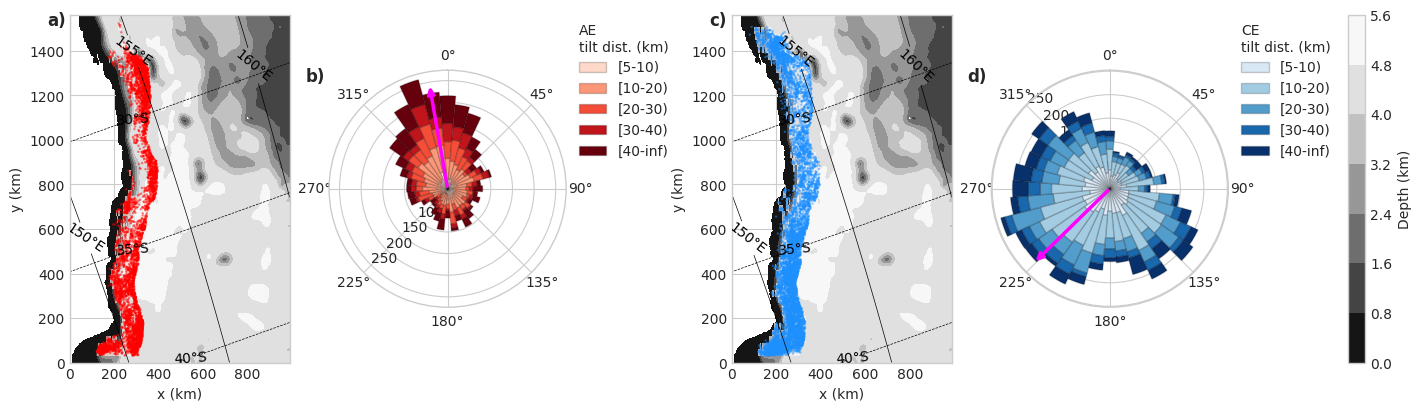

High Ro
AE mean tilt dir -27, tilt dis 20 km
CE mean tilt dir -58, tilt dis 15 km


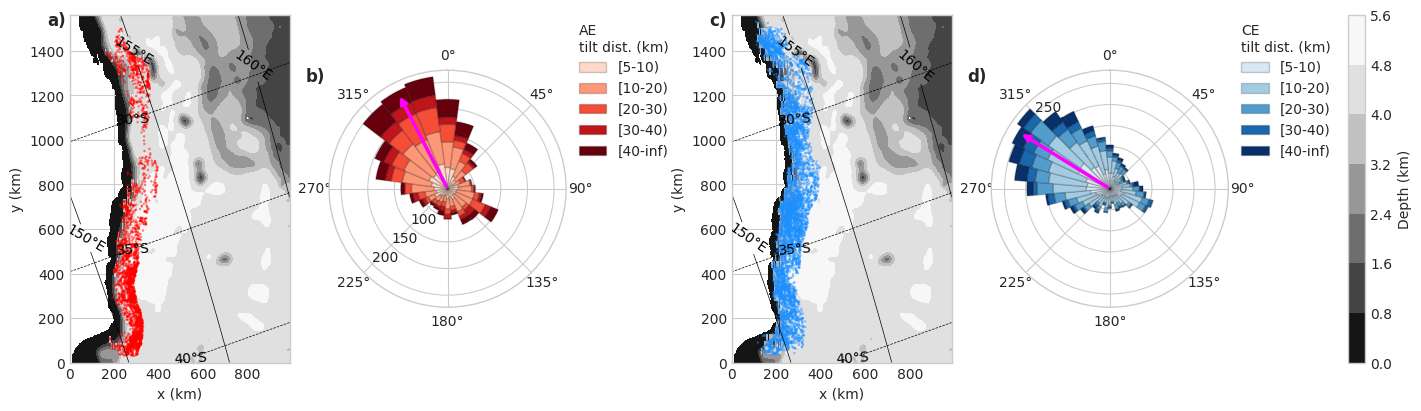

In [6]:
LAT_THRESH = 35
for k, title in enumerate(['Low Ro', 'High Ro']):
    if k==0:
        df = df_eddies[(df_eddies.Ro.abs()<.5)&(df_eddies.Region.isin(['S1','S2']))].copy()
    else:
        df = df_eddies[(df_eddies.Ro.abs()>=.5)&(df_eddies.Region.isin(['S1','S2']))].copy()
    print(title)
    fig, axs = tilt.plot_tilt_summary(df, grid)

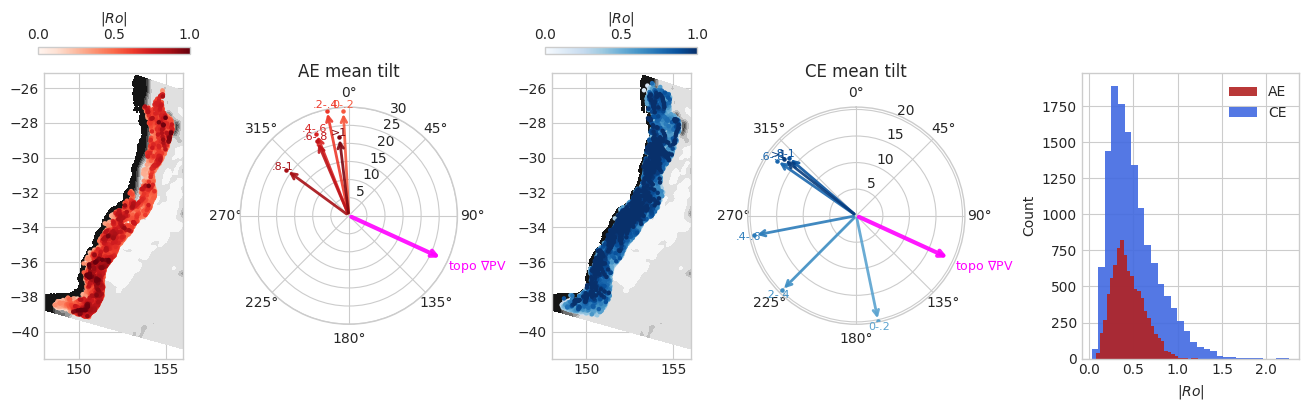

In [7]:
ro_bins=[0,.2,.4,.6,.8,1,np.inf]
labels=['0-.2','.2-.4','.4-.6','.6-.8','.8-1','>1']
vectors={'AE':{'theta':[],'r':[]},'CE':{'theta':[],'r':[]}}

for lo,hi in zip(ro_bins[:-1],ro_bins[1:]):
    d=df_eddies[(df_eddies.Ro.abs()>=lo)&(df_eddies.Ro.abs()<hi)&
                 (df_eddies.Region.isin(['S1','S2']))&(df_eddies.TiltDis>=5)].copy()
    for cyc in ['AE','CE']:
        sub=d[d.Cyc.eq(cyc)].dropna(subset=['TiltDir','TiltDis'])
        theta=np.deg2rad(sub.TiltDir)
        vectors[cyc]['theta'].append(np.arctan2(np.mean(np.sin(theta)),np.mean(np.cos(theta)))%(2*np.pi))
        vectors[cyc]['r'].append(sub.TiltDis.mean())

topo=df_eddies[df_eddies.Region.isin(['S1','S2'])].dropna(subset=['PV_grad_topo_x','PV_grad_topo_y'])
topo_theta=np.arctan2(topo.PV_grad_topo_x.mean(),topo.PV_grad_topo_y.mean())%(2*np.pi)

fig=plt.figure(figsize=(13,4),constrained_layout=True)
gs=fig.add_gridspec(1,5,width_ratios=[.7,1,.7,1,1])
axs=[fig.add_subplot(gs[0]),fig.add_subplot(gs[1],projection='polar'),
     fig.add_subplot(gs[2]),fig.add_subplot(gs[3],projection='polar'),fig.add_subplot(gs[4])]

for i,(cyc,cmap) in enumerate(zip(['AE','CE'],['Reds','Blues'])):
    ax,axp=axs[2*i],axs[2*i+1]

    bath=ax.contourf(grid.lon_rho,grid.lat_rho,np.where(grid.mask_rho,grid.h/1e3,np.nan),cmap='Greys_r')
    d=df_eddies[df_eddies.Region.isin(['S1','S2'])&df_eddies.Cyc.eq(cyc)].copy()
    d=d.assign(Ro_abs=d.Ro.abs()).sort_values('Ro_abs')
    sc=ax.scatter(d.lon,d.lat,c=d.Ro_abs,cmap=cmap,s=5,vmin=0,vmax=1)
    fig.colorbar(sc,ax=ax,orientation='horizontal',location='top',pad=.05,label=r'$|Ro|$')
    ax.set_aspect('equal',adjustable='box'); ax.set_xlim(148,156)

    theta=np.array(vectors[cyc]['theta']); r=np.array(vectors[cyc]['r'])
    colors=getattr(plt.cm,cmap)(np.linspace(.55,.95,len(labels)))
    axp.set_theta_zero_location('N'); axp.set_theta_direction(-1)
    for th,rr,label,color in zip(theta,r,labels,colors):
        axp.annotate('',xy=(th,rr),xytext=(0,0),arrowprops=dict(arrowstyle='->',color=color,lw=2,alpha=.9))
        axp.scatter(th,rr,color=color,s=5,zorder=3)
        axp.text(th,rr*1.06,label,ha='center',va='center',fontsize=8,color=color)

    rmax=axp.get_ylim()[1]
    axp.annotate('',xy=(topo_theta,.95*rmax),xytext=(topo_theta,0),
                 arrowprops=dict(arrowstyle='->',color='magenta',lw=3,alpha=.9))
    axp.text(topo_theta,1.3*rmax,r'topo $\nabla$PV',color='magenta',ha='center',va='bottom',fontsize=9)
    axp.set_title(f'{cyc} mean tilt')

# Ro histogram
df=df_eddies[df_eddies.Region.isin(['S1','S2'])].copy()
df['Ro_abs']=df.Ro.abs()
ax=axs[4]
zorder = 2
for cyc,c in [('AE','firebrick'), ('CE','royalblue')]:
    df.loc[df.Cyc.eq(cyc),'Ro_abs'].hist(ax=ax,bins=30,alpha=.9,color=c,label=cyc, zorder=zorder)
    zorder -= 1
# ax.axvline(.5,color='r',ls='--',lw=1.5)
ax.set(xlabel=r'$|Ro|$',ylabel='Count')
ax.legend(frameon=False)

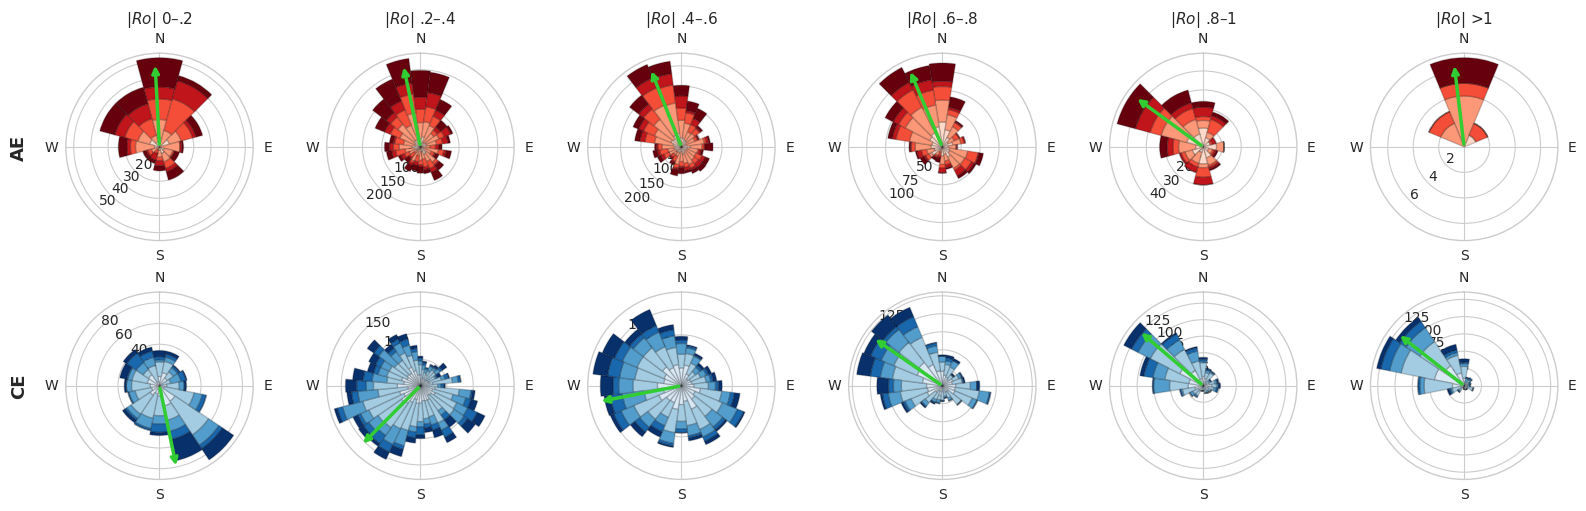

In [8]:
ro_bins = [0,.2,.4,.6,.8,1,np.inf]
labels = ['0–.2','.2–.4','.4–.6','.6–.8','.8–1','>1']
mag_bins = (0,10,20,30,40,np.inf)

fig, axs = plt.subplots(2,6,figsize=(16,5),subplot_kw={'projection':'polar'},constrained_layout=True)

for i,cyc in enumerate(['AE','CE']):
    for j,(lo,hi,label) in enumerate(zip(ro_bins[:-1],ro_bins[1:],labels)):
        ax = axs[i,j]
        d = df_eddies[(df_eddies.Cyc.eq(cyc)) &
                      (df_eddies.Region.isin(['S1','S2'])) &
                      (df_eddies.Ro.abs()>=lo) & (df_eddies.Ro.abs()<hi) &
                      (df_eddies.TiltDis>=5)].dropna(subset=['TiltDir','TiltDis']).copy()

        tilt.plot_windrose(ax,d,mag_bins=mag_bins,mag='TiltDis',theta='TiltDir')

        # circular mean tilt direction
        theta = np.deg2rad(d.TiltDir)
        mean_theta = np.arctan2(np.mean(np.sin(theta)),np.mean(np.cos(theta)))%(2*np.pi)
        rmax = ax.get_ylim()[1]
        ax.annotate('',xy=(mean_theta,.9*rmax),xytext=(mean_theta,0),
                    arrowprops=dict(arrowstyle='->',color='limegreen',lw=2.5,zorder=10))

        ax.set_title(fr'$|Ro|$ {label}' if i==0 else '',fontsize=11)
        ax.set_xticks(np.deg2rad([0,90,180,270]))
        ax.set_xticklabels(['N','E','S','W'])
        if j==0: ax.text(-.25,.5,cyc,transform=ax.transAxes,rotation=90,ha='center',va='center',fontsize=13,fontweight='bold')

plt.show()


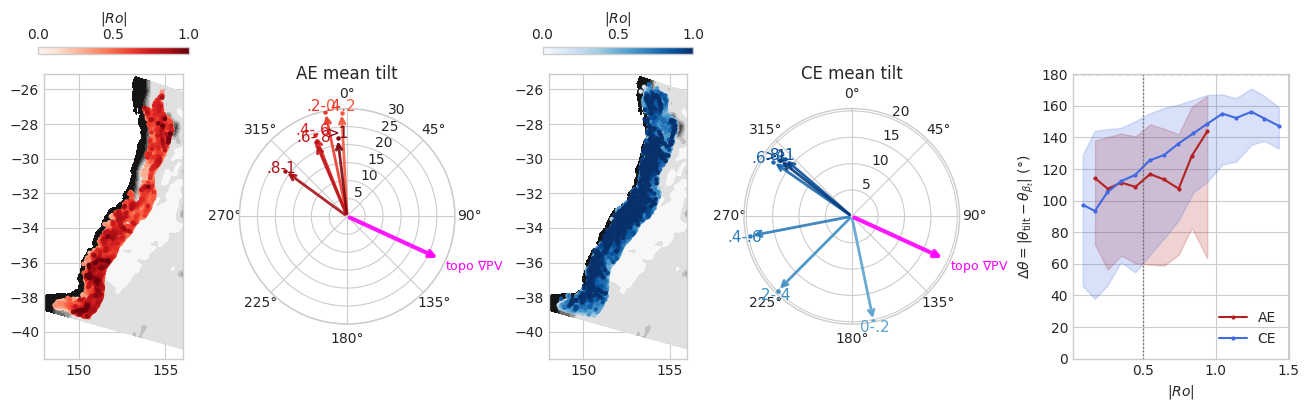

In [9]:
ro_bins=[0,.2,.4,.6,.8,1,np.inf]
labels=['0-.2','.2-.4','.4-.6','.6-.8','.8-1','>1']
vectors={'AE':{'theta':[],'r':[]},'CE':{'theta':[],'r':[]}}

for lo,hi in zip(ro_bins[:-1],ro_bins[1:]):
    d=df_eddies[(df_eddies.Ro.abs()>=lo)&(df_eddies.Ro.abs()<hi)&
                 (df_eddies.Region.isin(['S1','S2']))&(df_eddies.TiltDis>=5)].copy()
    for cyc in ['AE','CE']:
        sub=d[d.Cyc.eq(cyc)].dropna(subset=['TiltDir','TiltDis'])
        theta=np.deg2rad(sub.TiltDir)
        vectors[cyc]['theta'].append(np.arctan2(np.mean(np.sin(theta)),np.mean(np.cos(theta)))%(2*np.pi))
        vectors[cyc]['r'].append(sub.TiltDis.mean())

topo=df_eddies[df_eddies.Region.isin(['S1','S2'])].dropna(subset=['PV_grad_topo_x','PV_grad_topo_y'])
topo_theta=np.arctan2(topo.PV_grad_topo_x.mean(),topo.PV_grad_topo_y.mean())%(2*np.pi)

fig=plt.figure(figsize=(13,4),constrained_layout=True)
gs=fig.add_gridspec(1,5,width_ratios=[.7,1,.7,1,1])
axs=[fig.add_subplot(gs[0]),fig.add_subplot(gs[1],projection='polar'),
     fig.add_subplot(gs[2]),fig.add_subplot(gs[3],projection='polar'),fig.add_subplot(gs[4])]

for i,(cyc,cmap) in enumerate(zip(['AE','CE'],['Reds','Blues'])):
    ax,axp=axs[2*i],axs[2*i+1]

    bath=ax.contourf(grid.lon_rho,grid.lat_rho,np.where(grid.mask_rho,grid.h/1e3,np.nan),cmap='Greys_r')
    d=df_eddies[df_eddies.Region.isin(['S1','S2'])&df_eddies.Cyc.eq(cyc)].copy()
    d=d.assign(Ro_abs=d.Ro.abs()).sort_values('Ro_abs')
    sc=ax.scatter(d.lon,d.lat,c=d.Ro_abs,cmap=cmap,s=5,vmin=0,vmax=1)
    fig.colorbar(sc,ax=ax,orientation='horizontal',location='top',pad=.05,label=r'$|Ro|$')
    ax.set_aspect('equal',adjustable='box'); ax.set_xlim(148,156)

    theta=np.array(vectors[cyc]['theta']); r=np.array(vectors[cyc]['r'])
    colors=getattr(plt.cm,cmap)(np.linspace(.55,.95,len(labels)))
    axp.set_theta_zero_location('N'); axp.set_theta_direction(-1)
    for th,rr,label,color in zip(theta,r,labels,colors):
        axp.annotate('',xy=(th,rr),xytext=(0,0),arrowprops=dict(arrowstyle='->',color=color,lw=2,alpha=.9))
        axp.scatter(th,rr,color=color,s=5,zorder=3)
        axp.text(th,rr*1.06,label,ha='center',va='center',fontsize=11,color=color)

    rmax=axp.get_ylim()[1]
    axp.annotate('',xy=(topo_theta,.95*rmax),xytext=(topo_theta,0),
                 arrowprops=dict(arrowstyle='->',color='magenta',lw=3,alpha=.9))
    axp.text(topo_theta,1.3*rmax,r'topo $\nabla$PV',color='magenta',ha='center',va='bottom',fontsize=9)
    axp.set_title(f'{cyc} mean tilt')

# Ro vs alignment
ax=axs[4]
for cyc,clr in [('AE','firebrick'),('CE','royalblue')]:
    df=df_eddies[(df_eddies.Cyc.eq(cyc))&(df_eddies.Region.isin(['S1','S2']))&(df_eddies.TiltDis>=5)].copy()
    df['Ro_abs']=df.Ro.abs()
    bins=np.arange(0,df.Ro_abs.max()+.1,.1)
    df['Ro_bin']=pd.cut(df.Ro_abs,bins)
    stats=df.groupby('Ro_bin',observed=True).agg(
        Ro=('Ro_abs','median'),dtheta=('dtheta_PV_grad_topo','median'),
        q25=('dtheta_PV_grad_topo',lambda x:x.quantile(.25)),
        q75=('dtheta_PV_grad_topo',lambda x:x.quantile(.75)),
        n=('dtheta_PV_grad_topo','count')).query('n>=20')
    ax.plot(stats.Ro,stats.dtheta,'o-',color=clr,label=cyc, markersize=2)
    ax.fill_between(stats.Ro,stats.q25,stats.q75,color=clr,alpha=.2)

ax.axhline(180,color='.4',ls='--',lw=1)
ax.axvline(.5,color='.4',ls=':',lw=1)
ax.set(xlabel=r'$|Ro|$',ylabel=r'$\Delta\theta=|\theta_{\text{tilt}}-\theta_{\beta_t}|$ (°)',ylim=(0,180))
ax.legend(frameon=False)

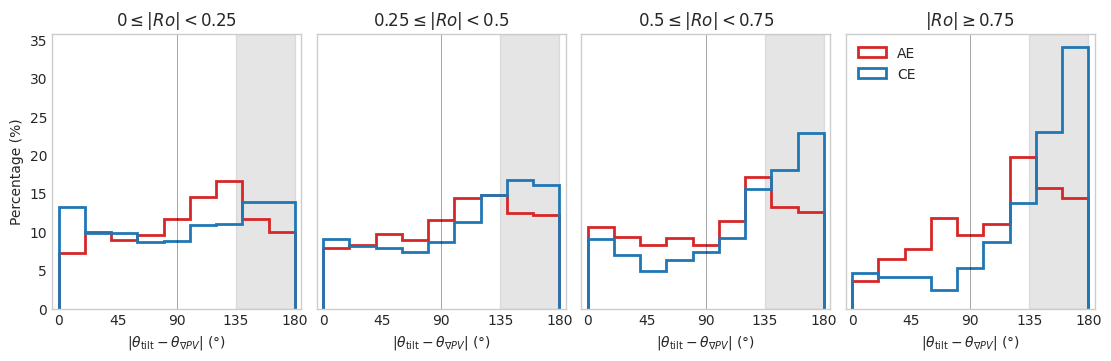

In [34]:
ALIGNMENT_DEG = 45

df_shelf = df_eddies[(df_eddies.Region.isin(['S1','S2'])) & (df_eddies.TiltDis>=5)].copy()
df_shelf['Ro_abs'] = df_shelf.Ro.abs()

bins = np.arange(0,181,20)
ro_bins = [(0,.25),(.25,.5),(.5,.75),(.75,np.inf)]
fig, axs = plt.subplots(1,4,figsize=(11,3.5),sharey=True,constrained_layout=True)

for ax,(lo,hi) in zip(axs,ro_bins):
    d = df_shelf[(df_shelf.Ro_abs>=lo) & (df_shelf.Ro_abs<hi)]
    for cyc,c in [('AE','tab:red'),('CE','tab:blue')]:
        x = d.loc[d.Cyc.eq(cyc),'dtheta_PV_grad'].dropna()
        ax.hist(x,bins=bins,weights=np.ones(len(x))*100/len(x),histtype='step',lw=2,color=c,label=cyc)
    ax.set(xlim=(-5,185),xticks=[0,45,90,135,180],
           xlabel=r'$|\theta_{\rm tilt}-\theta_{\nabla PV}|$ (°)',
           title=fr'${lo:g}\leq |Ro|<{hi:g}$' if np.isfinite(hi) else r'$|Ro|\geq0.75$')
    ax.axvspan(180-ALIGNMENT_DEG,180,color='grey',alpha=.2)
    ax.axvline(90,lw=.5,alpha=.5,c='k'); ax.grid(False)

axs[0].set_ylabel('Percentage (%)')
axs[-1].legend(frameon=False)
plt.show()

Text(0, 0.5, 'PV')

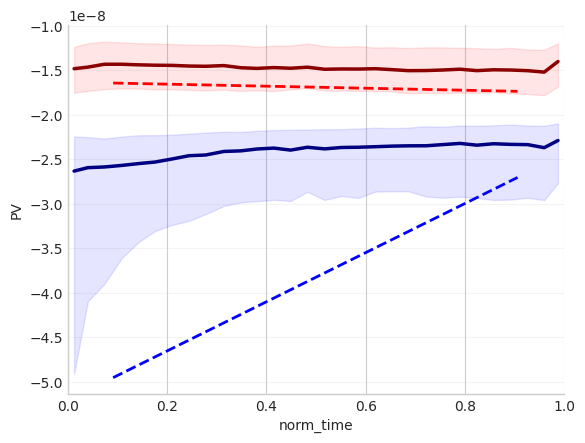

In [11]:
fig, ax = plt.subplots()
df_eddies['norm_time'] = df_eddies.groupby('Eddy')['Day'].transform(lambda x: (x-x.min())/(x.max()-x.min()))
ax = tilt.binned_tilt_panel(ax, df_eddies, "norm_time", "norm_time", ycol='PV',xlim=(0,1), linfit=True)
ax.set_ylabel('PV')

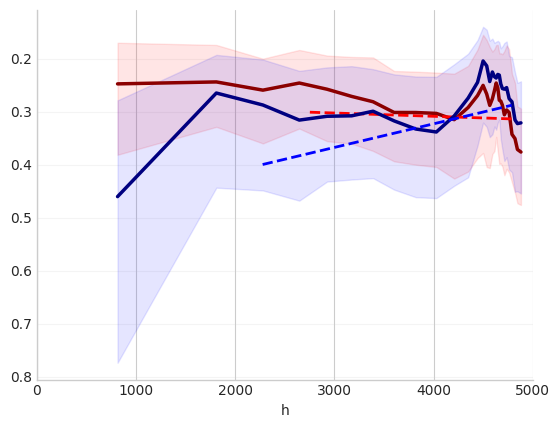

In [12]:
fig, ax = plt.subplots()
df_eddies['Ro_abs'] = df_eddies.Ro.abs()
ax = tilt.binned_tilt_panel(ax, df_eddies, "h", "h", ycol='Ro_abs',xlim=(0,5000), linfit=True)
ax.invert_yaxis()

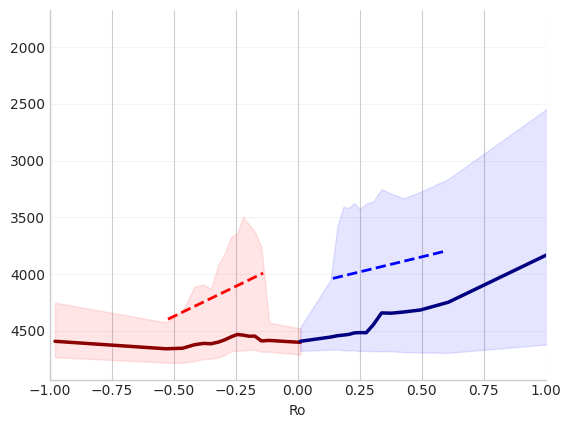

In [13]:
fig, ax = plt.subplots()
df_eddies['Ro_abs'] = df_eddies.Ro.abs()
ax = tilt.binned_tilt_panel(ax, df_eddies, "Ro", "Ro", ycol='h',xlim=(-1,1), linfit=True)
ax.invert_yaxis()

#### off shelf

Ro 0.0–0.2: n=30081
AE mean tilt dir 24, tilt dis 26 km
CE mean tilt dir 141, tilt dis 23 km


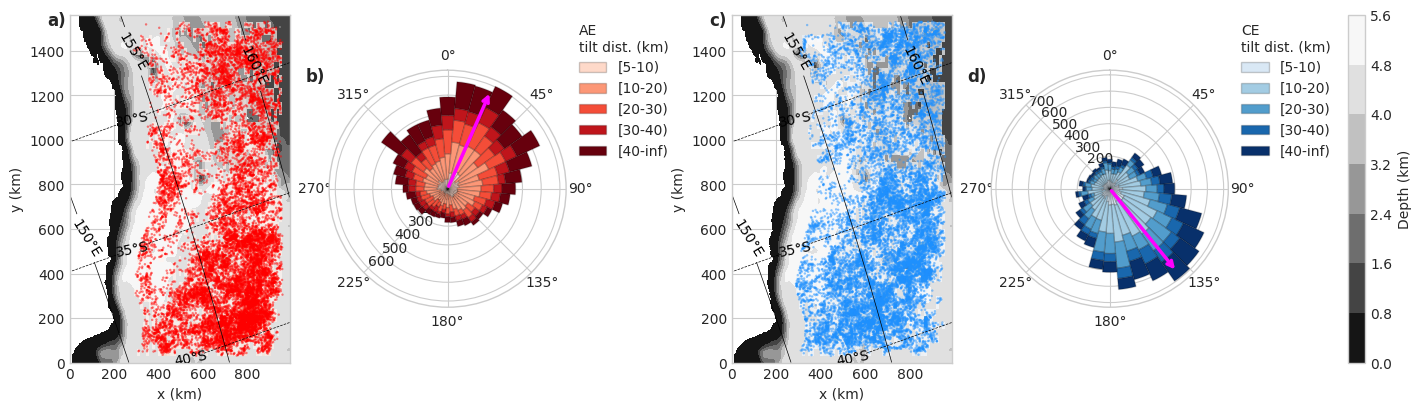

Ro 0.2–0.4: n=49232
AE mean tilt dir 20, tilt dis 28 km
CE mean tilt dir 143, tilt dis 23 km


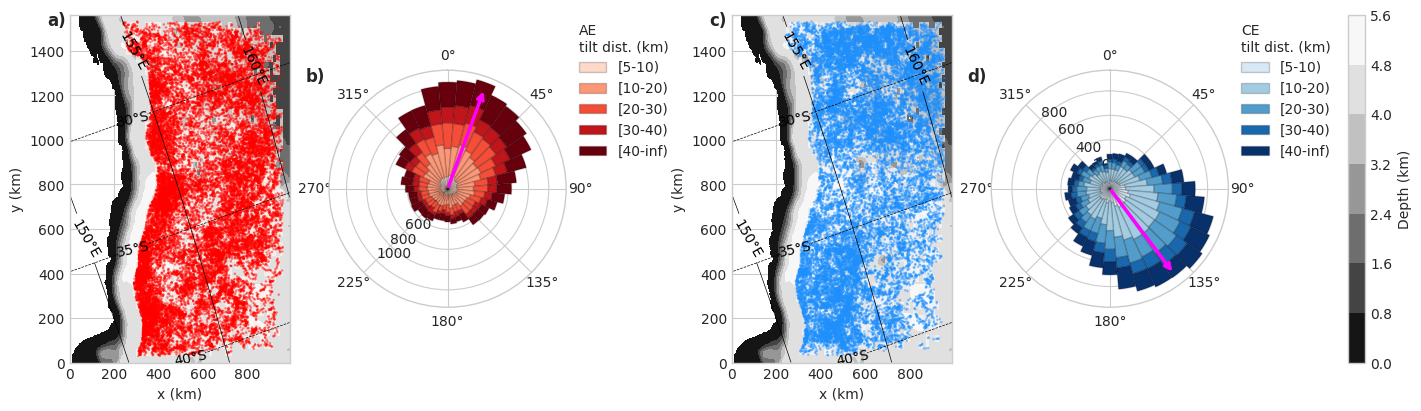

Ro 0.4–0.6: n=16216
AE mean tilt dir -1, tilt dis 24 km
CE mean tilt dir 154, tilt dis 22 km


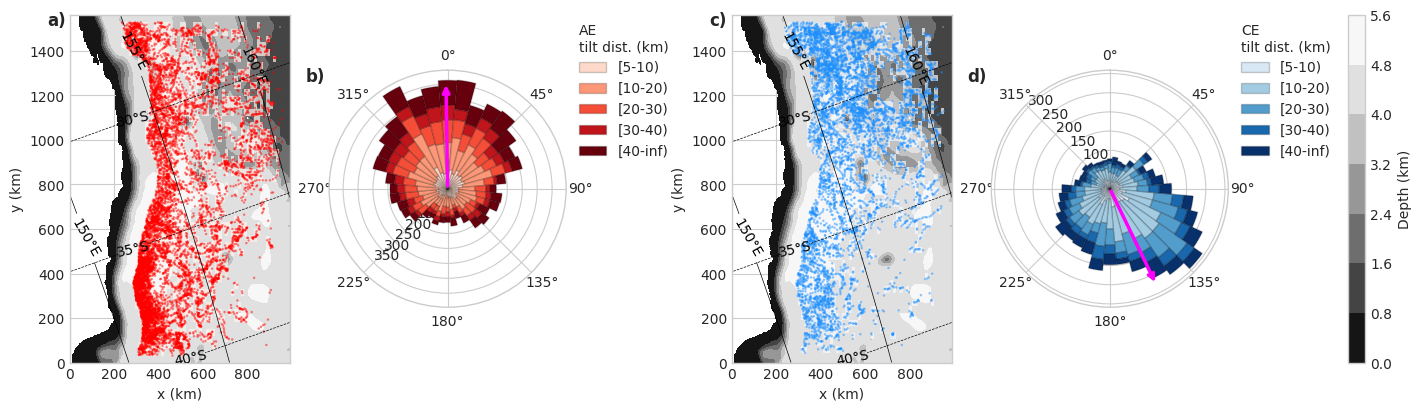

Ro 0.6–0.8: n=2717
AE mean tilt dir -27, tilt dis 21 km
CE mean tilt dir 165, tilt dis 20 km


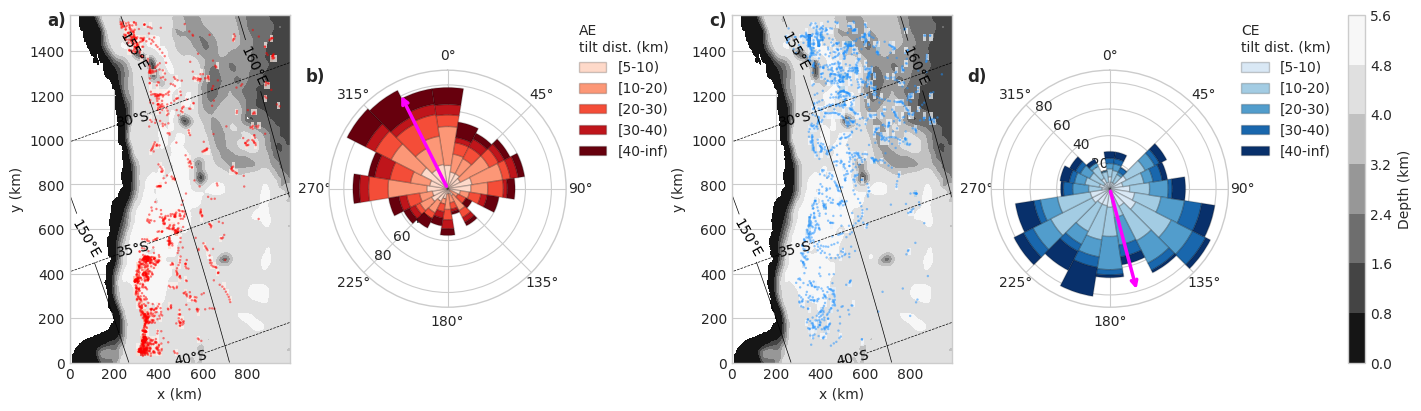

Ro 0.8–1.0: n=481
AE mean tilt dir -123, tilt dis 30 km
CE mean tilt dir 157, tilt dis 22 km


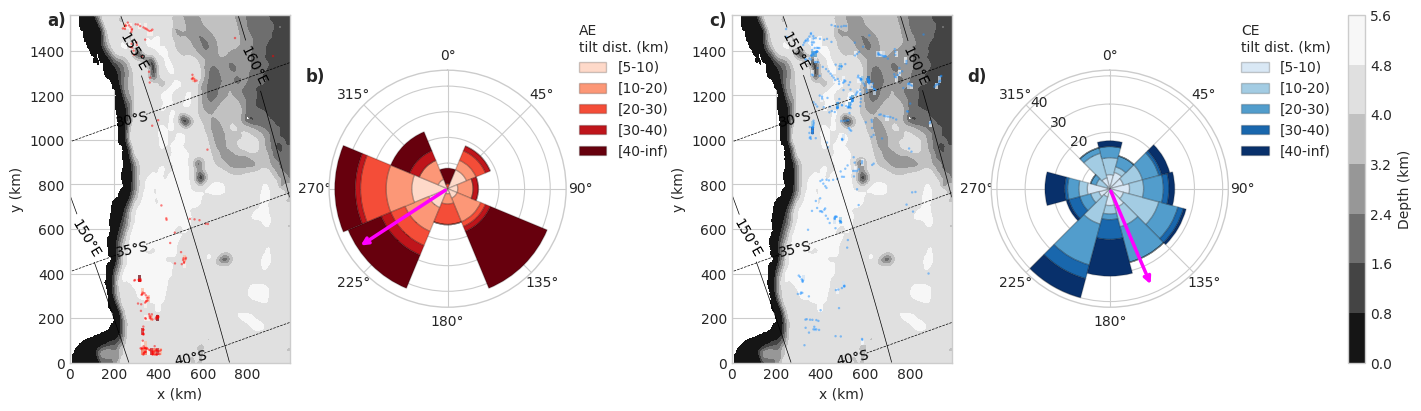

Ro 1.0–1.2: n=91
AE mean tilt dir -91, tilt dis 28 km
CE mean tilt dir -172, tilt dis 24 km


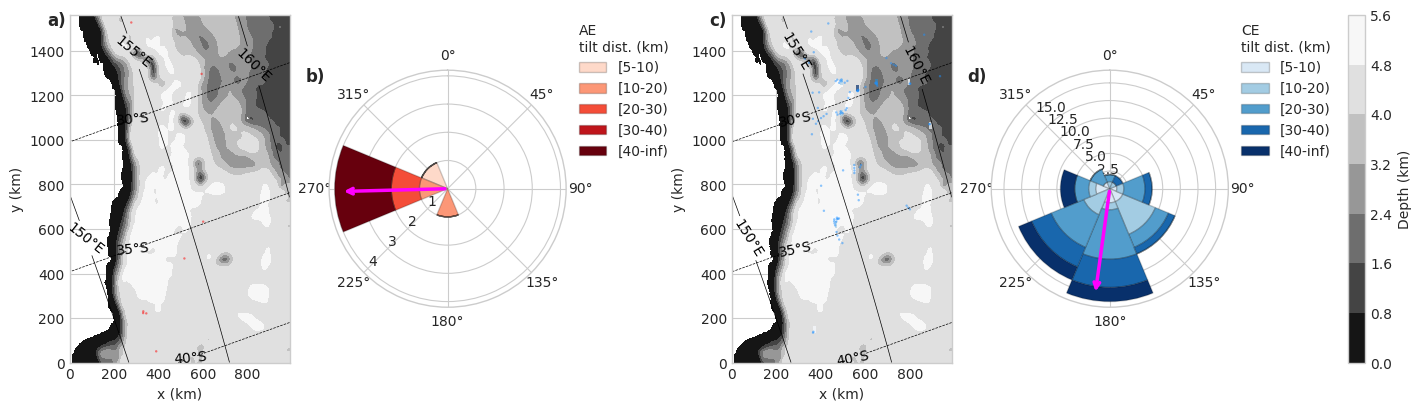

In [14]:
ro_bins=np.arange(0,1.2+.2,.2)

for lo,hi in zip(ro_bins[:-1],ro_bins[1:]):
    df=df_eddies[(df_eddies.Ro.abs()>=lo)&(df_eddies.Ro.abs()<hi)&
                 (df_eddies.Region.isin(['U1','U2','D1','D2']))].copy()
    print(f'Ro {lo:.1f}–{hi:.1f}: n={len(df)}')
    fig,axs=tilt.plot_tilt_summary(df, grid)

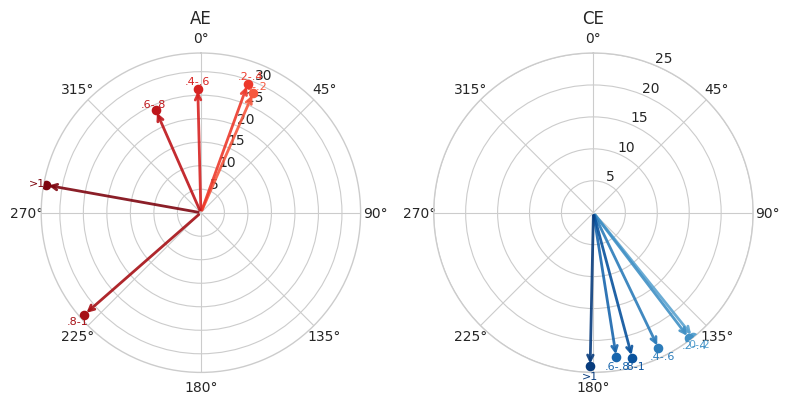

In [15]:
ro_bins=[0,.2,.4,.6,.8,1,np.inf]
labels=['0-.2','.2-.4','.4-.6','.6-.8','.8-1','>1']

vectors={'AE':{'theta':[],'r':[]},'CE':{'theta':[],'r':[]}}

for lo,hi in zip(ro_bins[:-1],ro_bins[1:]):
    d=df_eddies[(df_eddies.Ro.abs()>=lo)&(df_eddies.Ro.abs()<hi)&
                 (df_eddies.Region.isin(['U1','U2','D1','D2']))&(df_eddies.TiltDis>=5)].copy()

    for cyc in ['AE','CE']:
        sub=d[d.Cyc.eq(cyc)].dropna(subset=['TiltDir','TiltDis'])
        theta=np.deg2rad(sub.TiltDir)
        theta_mean=np.arctan2(np.mean(np.sin(theta)),np.mean(np.cos(theta)))%(2*np.pi)
        vectors[cyc]['theta'].append(theta_mean)
        vectors[cyc]['r'].append(sub.TiltDis.mean())

fig,axs=plt.subplots(1,2,figsize=(8,4),subplot_kw={'projection':'polar'})

for ax,cyc,cmap in zip(axs,['AE','CE'],['Reds','Blues']):
    theta=np.array(vectors[cyc]['theta']); r=np.array(vectors[cyc]['r'])
    colors=getattr(plt.cm,cmap)(np.linspace(.55,.95,len(labels)))
    ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)

    for th,rr,label,color in zip(theta,r,labels,colors):
        ax.annotate('',xy=(th,rr),xytext=(0,0),
                    arrowprops=dict(arrowstyle='->',color=color,lw=2,alpha=.9))
        ax.scatter(th,rr,color=color,s=35,zorder=3)
        ax.text(th,rr*1.06,label,ha='center',va='center',fontsize=8,color=color)

    ax.set_title(cyc)

plt.tight_layout()

#### Shear

In [16]:
sx = 'clim_upper_minus_deep_east_ms'
sy = 'clim_upper_minus_deep_north_ms'

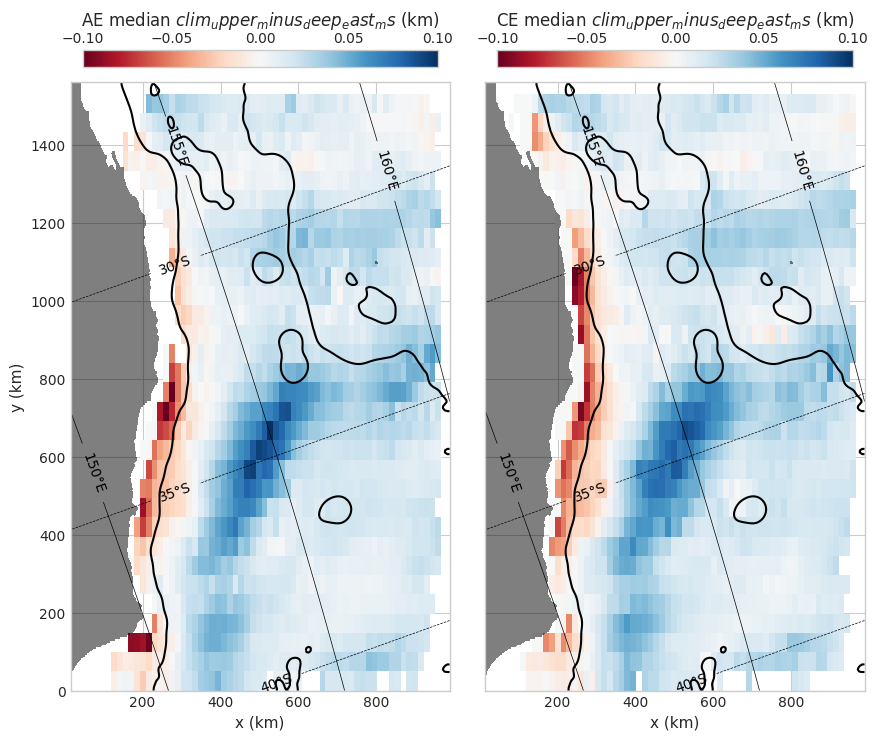

In [17]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric=sx, vmin=-.1, vmax=.1, cmaps={'AE': 'RdBu', 'CE': 'RdBu'})

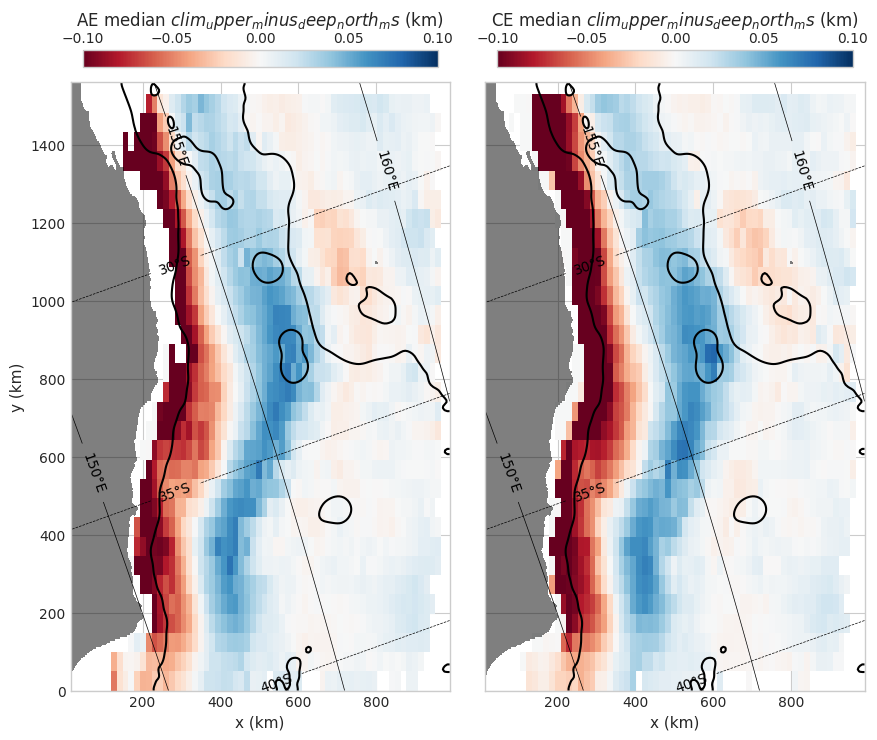

In [18]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric=sy, vmin=-.1, vmax=.1, cmaps={'AE': 'RdBu', 'CE': 'RdBu'})

In [19]:
df_eddies.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       ...
       'clim_200_east_ms', 'clim_200_north_ms', 'clim_500_east_ms',
       'clim_500_north_ms', 'clim_surface_east_ms', 'clim_surface_north_ms',
       'clim_upper_minus_deep_east_ms', 'clim_upper_minus_deep_north_ms',
       'norm_time', 'Ro_abs'],
      dtype='object', length=103)

<Axes: xlabel='clim_upper_minus_deep_east_ms', ylabel='Tilt distance (km)'>

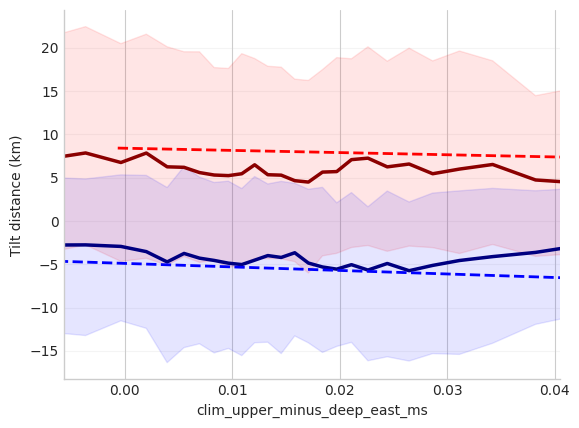

In [20]:
fig, ax = plt.subplots()
df_eddies['TiltDis_x'] = np.cos(np.deg2rad(df_eddies.TiltDir)) * df_eddies.TiltDis
df_eddies['TiltDis_y'] = np.sin(np.deg2rad(df_eddies.TiltDir)) * df_eddies.TiltDis
tilt.binned_tilt_panel(ax, df_eddies, sx, sx, ylabel="Tilt distance (km)", ycol='TiltDis_x', linfit=True)

<Axes: xlabel='clim_upper_minus_deep_east_ms', ylabel='Tilt distance (km)'>

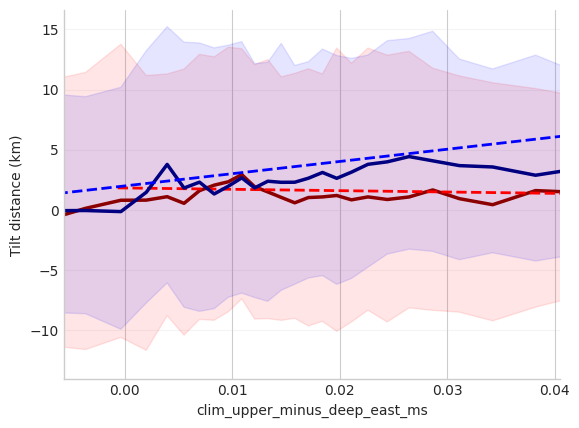

In [21]:
fig, ax = plt.subplots()
tilt.binned_tilt_panel(ax, df_eddies, sx, sx, ylabel="Tilt distance (km)", ycol='TiltDis_y', linfit=True)

<Axes: xlabel='clim_upper_minus_deep_north_ms', ylabel='Tilt distance (km)'>

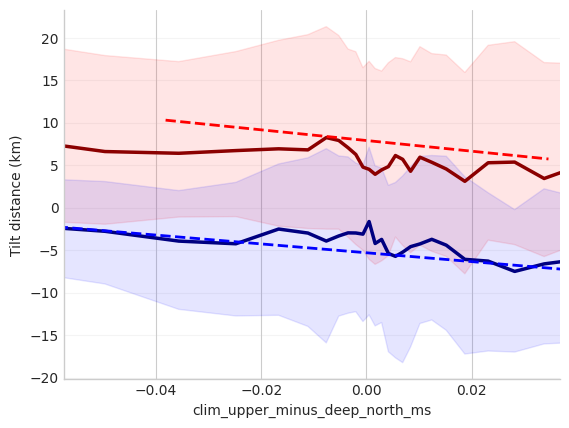

In [22]:
fig, ax = plt.subplots()
tilt.binned_tilt_panel(ax, df_eddies, sy, sy, ylabel="Tilt distance (km)", ycol='TiltDis_x', linfit=True)

<Axes: xlabel='clim_upper_minus_deep_north_ms', ylabel='Tilt distance (km)'>

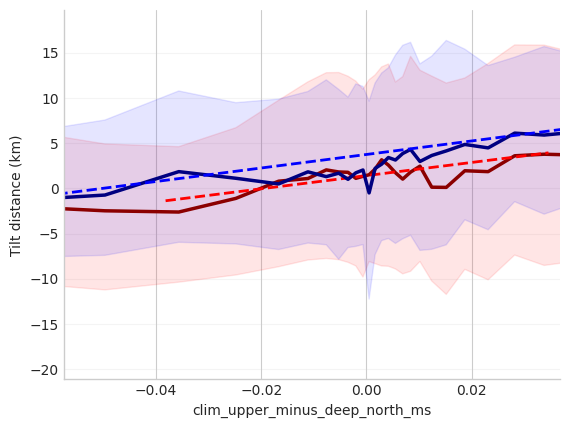

In [23]:
fig, ax = plt.subplots()
tilt.binned_tilt_panel(ax, df_eddies, sy, sy, ylabel="Tilt distance (km)", ycol='TiltDis_y', linfit=True)

<Axes: >

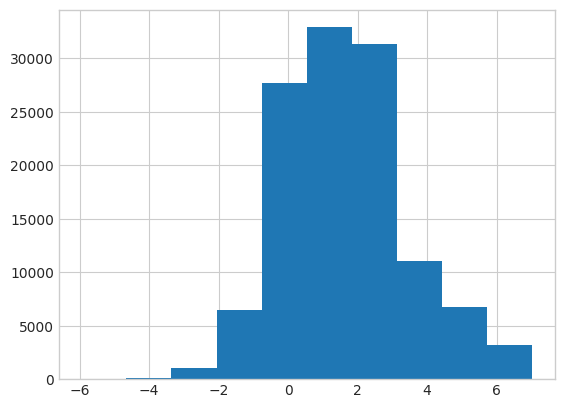

In [24]:
df_eddies['topo_plan_ratio'].hist()

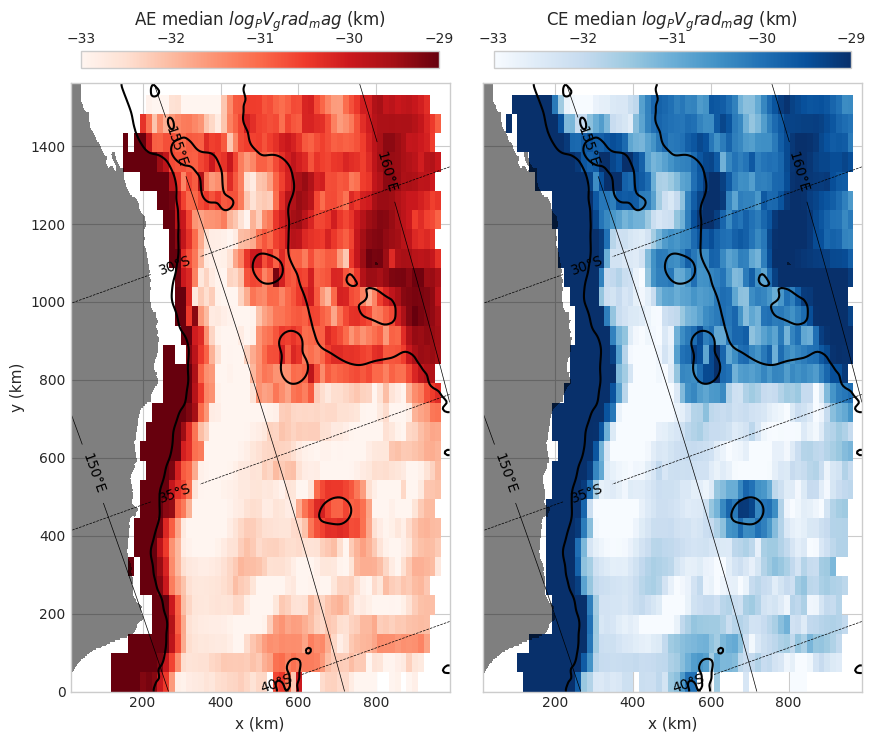

In [25]:
df_eddies['log_PV_grad_mag'] = np.log(df_eddies.PV_grad_mag)
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric='log_PV_grad_mag', vmin=-33, vmax=-29)

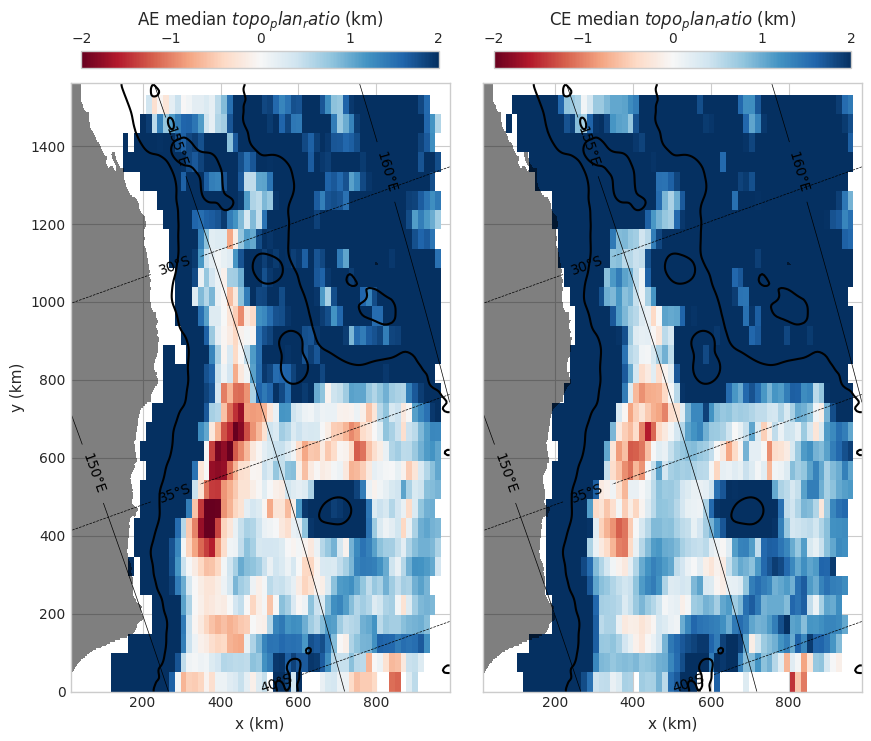

In [26]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric='topo_plan_ratio', vmin=-2, vmax=2, cmaps={'AE': 'RdBu', 'CE': 'RdBu'})

In [27]:
def plot_binned_direction_map(
    df_data: pd.DataFrame,
    grid: grid,
    *,
    theta='PV_grad_theta',
    bin_size=100,
    min_count=1,
    arrow_scale=.35,
    cmaps={'AE':'firebrick', 'CE':'royalblue'},
    figsize=(9, 8),
    fig=None,
    axs=None,
    show=True
):
    df_data = df_data.copy()
    xmin, xmax = grid.X_grid.min(), grid.X_grid.max()
    ymin, ymax = grid.Y_grid.min(), grid.Y_grid.max()
    xbins = np.arange(xmin, xmax + bin_size, bin_size)
    ybins = np.arange(ymin, ymax + bin_size, bin_size)
    xc = (xbins[:-1] + xbins[1:])/2
    yc = (ybins[:-1] + ybins[1:])/2
    X, Y = np.meshgrid(xc, yc)

    if axs is None:
        fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for ax, cyc in zip(axs, ['AE', 'CE']):
        df = df_data[df_data.Cyc.eq(cyc)].dropna(subset=['xc','yc',theta]).copy()
        ang = np.deg2rad(df[theta].to_numpy())
        x, y = df.xc.to_numpy(), df.yc.to_numpy()

        U, _, _ = np.histogram2d(y, x, bins=[ybins, xbins], weights=np.cos(ang))
        V, _, _ = np.histogram2d(y, x, bins=[ybins, xbins], weights=np.sin(ang))
        N, _, _ = np.histogram2d(y, x, bins=[ybins, xbins])
        U = np.divide(U, N, out=np.full_like(U, np.nan), where=N >= min_count)
        V = np.divide(V, N, out=np.full_like(V, np.nan), where=N >= min_count)

        # normalise arrows: direction only
        M = np.hypot(U, V)
        Un = np.divide(U, M, out=np.full_like(U, np.nan), where=M > 0)
        Vn = np.divide(V, M, out=np.full_like(V, np.nan), where=M > 0)

        ax.quiver(X, Y, Un, Vn, color=cmaps[cyc], angles='xy', scale_units='xy',
                  scale=1/(bin_size*arrow_scale), width=.004)

        ax.contour(grid.X_grid, grid.Y_grid, grid.h, levels=[4000], colors='k')
        ax.contourf(grid.X_grid, grid.Y_grid, np.where(grid.mask_rho == 0, 1, np.nan),
                    levels=[.5,1.5], colors=['k'], alpha=.5)
        ax = tilt.lat_lon_contours(ax, grid)
        ax.set_xlim(15, xmax); ax.set_ylim(ymin, ymax)
        ax.set(title=cyc, xlabel='x (km)', aspect='equal')

    axs[0].set_ylabel('y (km)')
    if show:
        plt.tight_layout(); plt.show()
    return fig, axs

In [28]:
df_eddies.columns

Index(['Eddy', 'Day', 'Cyc', 'lon', 'lat', 'ic', 'jc', 'xc', 'yc', 'w',
       ...
       'clim_500_north_ms', 'clim_surface_east_ms', 'clim_surface_north_ms',
       'clim_upper_minus_deep_east_ms', 'clim_upper_minus_deep_north_ms',
       'norm_time', 'Ro_abs', 'TiltDis_x', 'TiltDis_y', 'log_PV_grad_mag'],
      dtype='object', length=106)

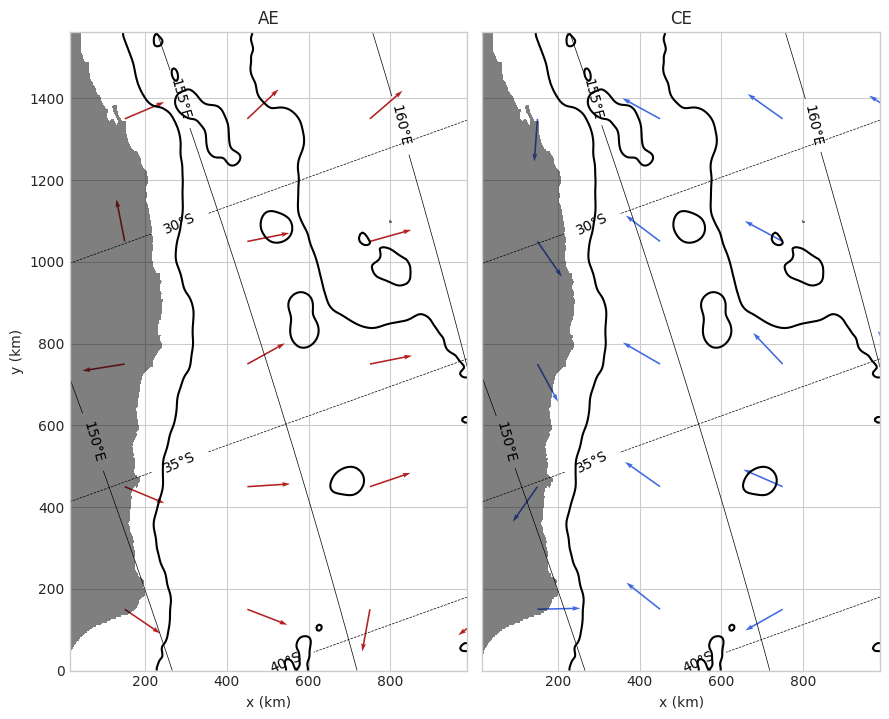

In [29]:
fig, axs = plot_binned_direction_map(df_eddies.copy(), grid, theta='TiltDir', bin_size=300)

In [30]:
def plot_binned_windrose_map(
    df_data: pd.DataFrame,
    grid: grid,
    *,
    theta='TiltDir',
    mag='TiltDis',
    bin_size=150,
    rose_size=100,
    min_count=10,
    mag_bins=(0,10,20,30,40,np.inf),
    figsize=(12,8),
    fig=None,
    axs=None,
    show=True
):
    df_data = df_data.copy()
    xmin, xmax = grid.X_grid.min(), grid.X_grid.max()
    ymin, ymax = grid.Y_grid.min(), grid.Y_grid.max()
    xbins = np.arange(xmin, xmax + bin_size, bin_size)
    ybins = np.arange(ymin, ymax + bin_size, bin_size)

    if axs is None:
        fig, axs = plt.subplots(1,2,figsize=figsize,sharey=True)

    for ax, cyc in zip(axs,['AE','CE']):
        df = df_data[df_data.Cyc.eq(cyc)].dropna(subset=['xc','yc',theta,mag]).copy()

        ax.contour(grid.X_grid,grid.Y_grid,grid.h,levels=[4000],colors='k',linewidths=1)
        ax.contourf(grid.X_grid,grid.Y_grid,np.where(grid.mask_rho==0,1,np.nan),
                    levels=[.5,1.5],colors=['k'],alpha=.5)
        ax = tilt.lat_lon_contours(ax,grid)
        ax.set_xlim(15,xmax); ax.set_ylim(ymin,ymax)
        ax.set(title=cyc,xlabel='x (km)',aspect='equal')

        for i in range(len(xbins)-1):
            for j in range(len(ybins)-1):
                d = df[df.xc.between(xbins[i],xbins[i+1],inclusive='left') &
                       df.yc.between(ybins[j],ybins[j+1],inclusive='left')]
                if len(d) < min_count: continue

                xc = (xbins[i]+xbins[i+1])/2
                yc = (ybins[j]+ybins[j+1])/2

                # convert data-coordinate centre/size to figure coordinates
                p0 = fig.transFigure.inverted().transform(ax.transData.transform((xc-rose_size/2,yc-rose_size/2)))
                p1 = fig.transFigure.inverted().transform(ax.transData.transform((xc+rose_size/2,yc+rose_size/2)))
                rax = fig.add_axes([p0[0],p0[1],p1[0]-p0[0],p1[1]-p0[1]],projection='polar')

                tilt.plot_windrose(rax,d,mag_bins=mag_bins,mag=mag,theta=theta)
                rax.set_title('')
                rax.set_xticklabels([])
                rax.set_yticklabels([])
                rax.grid(False)
                rax.spines['polar'].set_linewidth(.4)
                rax.patch.set_alpha(0)

    axs[0].set_ylabel('y (km)')
    if show: plt.show()
    return fig, axs

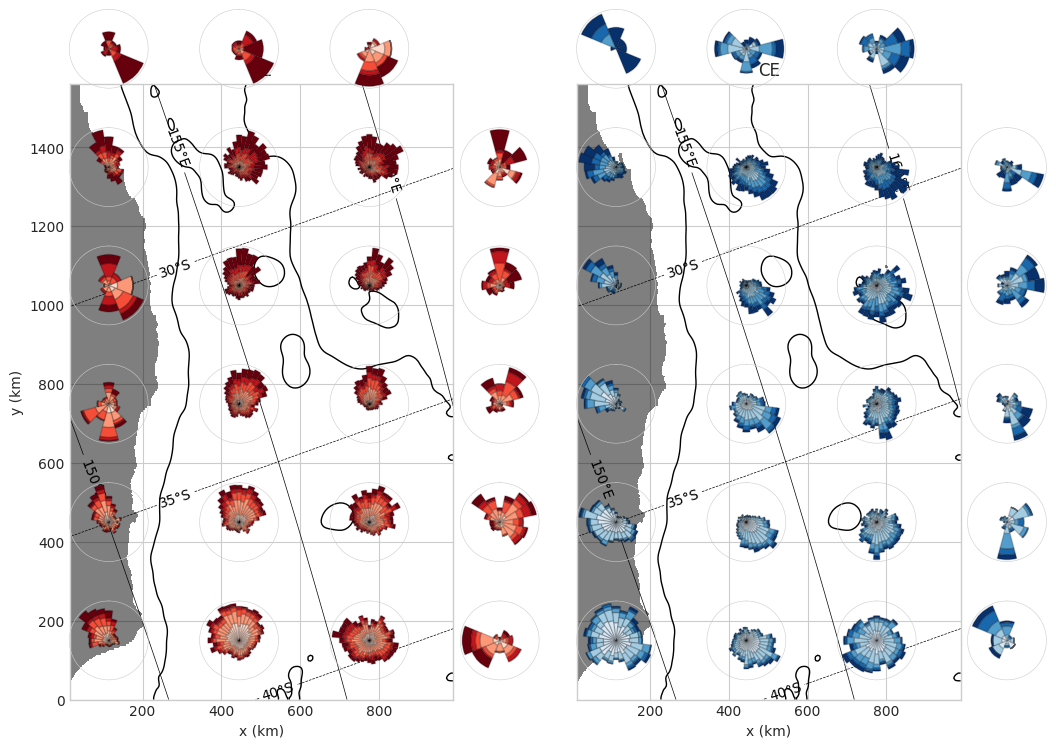

In [31]:
fig, axs = plot_binned_windrose_map(
    df_eddies.copy(), grid,
    theta='TiltDir', mag='TiltDis',
    bin_size=300, rose_size=200,
    min_count=20,
    mag_bins=(0,10,20,30,40,np.inf)
)

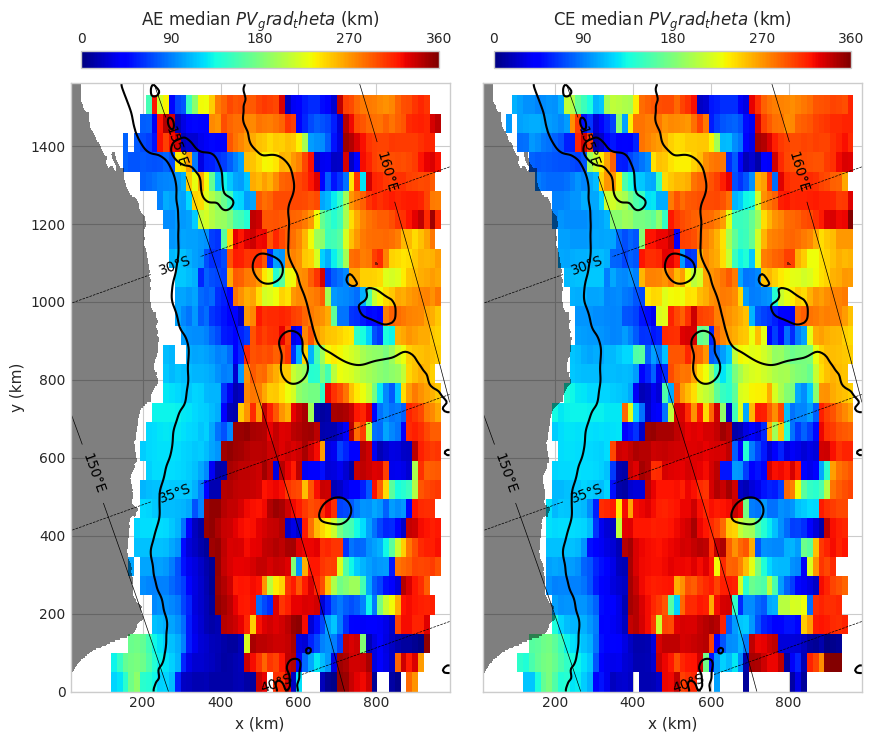

In [32]:
fig, axs = tilt.plot_binned_median_map(df_eddies.copy(), grid, 
                                       metric='PV_grad_theta', vmin=0, vmax=360, cmaps={'AE': 'jet', 'CE': 'jet'})